# Solve 5 seeds per point cloud size and investigate solving duration

In [7]:
import sys

sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np

from typing import Any
from icp import ICP, MultiStartICP
from experiment_runner import fit_multi_seed, MultiSeedSyntheticICPResult
from matcher import NearestNeighborMatcher
from error_metrics import convergence_to_global_opt_ratio, convergence_ratio
from visualization import ErrorMetricsVisualizer, TimeVisualizer
from algebra_utils import sample_dispersed_rotations
import numpy as np
from sklearn.cluster import DBSCAN

from feature_extractor import RobustGeometricFeatureExtractor
from hpo import _FEATURE_EXTRACTOR_DIM
from trimmer import ClusteringTrimmer

from tabulate import tabulate

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 5
N_STARTS = 13

In [8]:
matcher = NearestNeighborMatcher(feature_extractor=None)
single_icp = ICP(matcher=matcher, max_iter=MAX_ITER, record_history=False)
nn_icp = MultiStartICP(
    single_icp,
    n_starts=N_STARTS,
    rotation_sampler=sample_dispersed_rotations
)
eps_scaling=0.1246
min_samples_scaling=0.7766
d = _FEATURE_EXTRACTOR_DIM["robust"]

In [9]:
seeds = list(range(N_SEEDS))
n_points = [1000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000]

results: list[MultiSeedSyntheticICPResult] = []
for n in n_points:
    eps = (2 * d) ** 0.5 * eps_scaling
    min_samples = max(2, int(np.log(n) * min_samples_scaling))
    trimmer=ClusteringTrimmer(
        feature_extractor=RobustGeometricFeatureExtractor(k=19), 
        min_cluster_fraction=0.0131,
        clusterer=DBSCAN(eps=eps, min_samples=min_samples)
    )
    experiment_kwargs: dict[str, Any] = {'n': n, 'noise_std': 0.01, 't_scale': 8, 'style': 'clustered'}
    result = fit_multi_seed(nn_icp, trimmer=trimmer, experiment_kwargs=experiment_kwargs, seeds=seeds)
    results.append(result)

Solving 5 seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Solving 5 seeds: 100%|██████████| 5/5 [04:11<00:00, 50.33s/it]


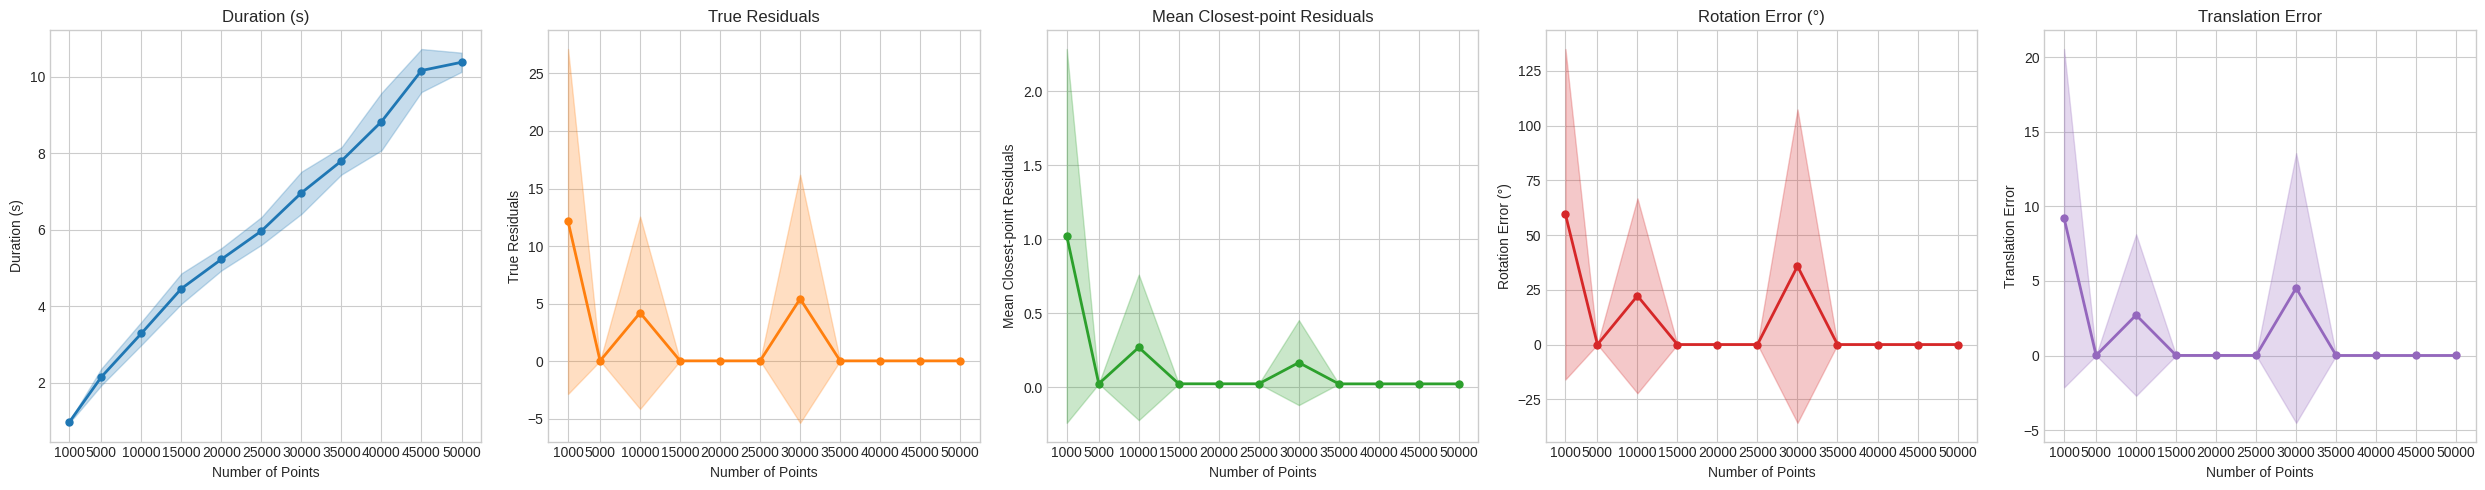

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
ErrorMetricsVisualizer.plot_parameter_sweep(
    axes=axes,
    data_per_metric=[np.array([result.durations_s for result in results]), np.array([result.mean_true_residuals for result in results]), np.array([result.mean_closest_point_residuals for result in results]), np.array([result.rotation_errors for result in results]), np.array([result.translation_errors for result in results])],
    y_labels=['Duration (s)', 'True Residuals', 'Mean Closest-point Residuals', 'Rotation Error (°)', 'Translation Error'],
    x_label='Number of Points',
    x = n_points
)
plt.tight_layout()
plt.savefig('../results/9_scaling_rainbow.png', dpi=300)
plt.show()